In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import stats

In [70]:
df = pd.read_csv('/home/antonio/Uni/lab4/esperienze/rh_t/Gruppo03_2025-12-9T10-48-29.csv',
                 header=None, names=['HR (%)', 'T (°C)', 't (s)'])
df

,HR (%),T (°C),t (s)
0,48.07,19.78,0.802
1,48.07,19.78,1.203
2,48.04,19.79,1.604
3,48.07,19.79,2.005
4,48.04,19.78,2.406
...,...,...,...
18484,50.46,20.96,7198.634
18485,50.49,20.95,7199.035
18486,50.50,20.96,7199.436
18487,50.49,20.95,7199.837


In [71]:
HR = df['HR (%)'].values
T  = df['T (°C)'].values
time = df['t (s)'].values
N  = len(df)

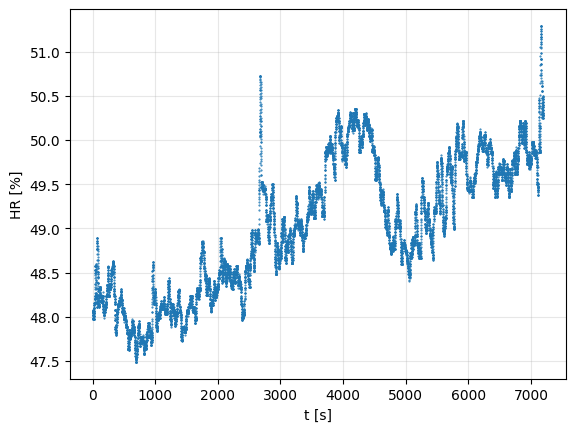

In [72]:
plt.plot(time, HR, marker='.', markersize=1, linestyle='None')
plt.xlabel('t [s]')
plt.ylabel('HR [%]')
plt.grid(alpha=0.3)
plt.show()

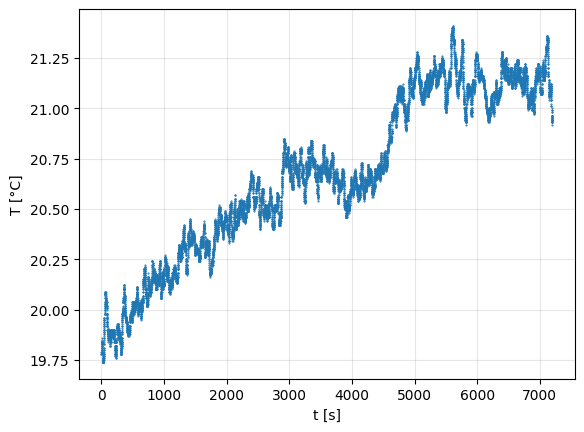

In [73]:
plt.plot(time, T, marker='.', markersize=1, linestyle='None')
plt.xlabel('t [s]')
plt.ylabel('T [°C]')
plt.grid(alpha=0.3)
plt.show()

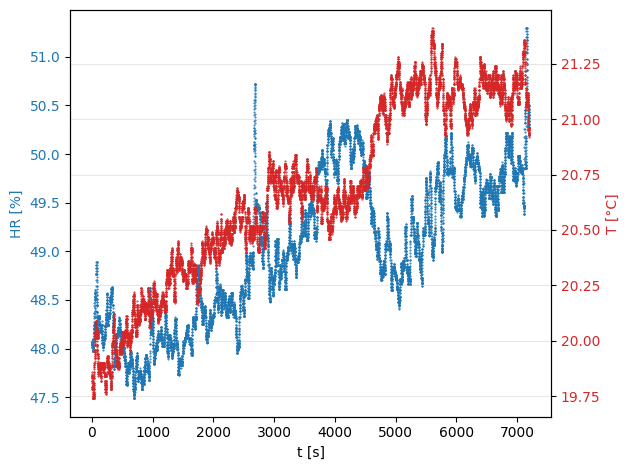

In [74]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('t [s]')
ax1.set_ylabel('HR [%]', color='tab:blue')
ax1.plot(time, HR, color='tab:blue', marker='.', markersize=1, linestyle='None', label='HR')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('T [°C]', color='tab:red')
ax2.plot(time, T, color='tab:red', marker='.', markersize=1, linestyle='None', label='T')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

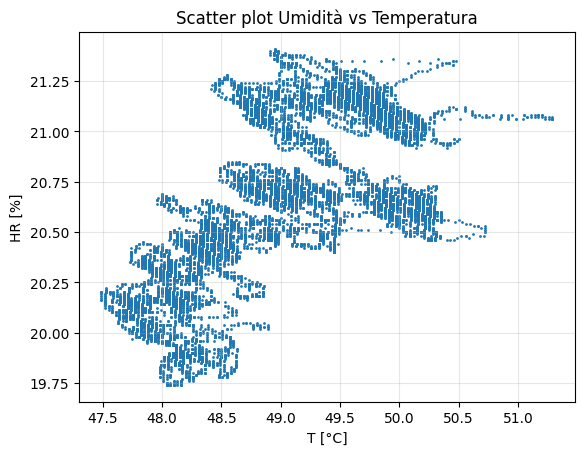

In [75]:
plt.scatter(HR, T, s=1)
# plt.scatter(T, HR, c=time, s=1)
plt.xlabel('T [°C]')
plt.ylabel('HR [%]')
plt.title('Scatter plot Umidità vs Temperatura')
# plt.colorbar(label='t [s]')
plt.grid(alpha=0.3)
plt.show()

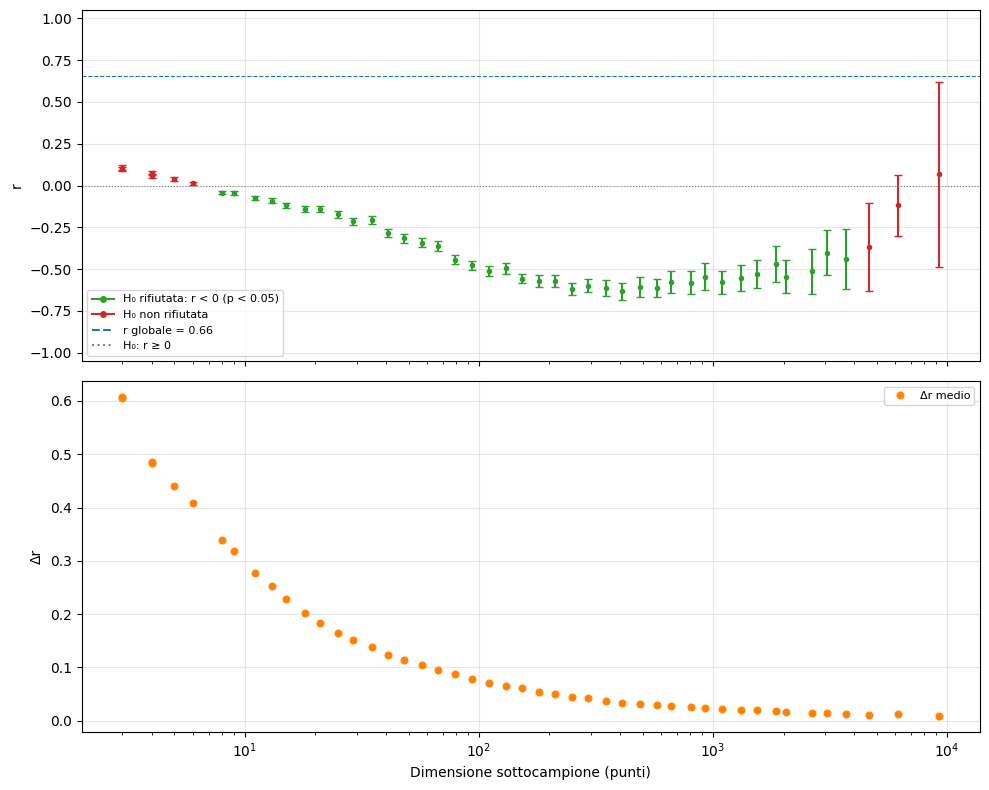

 n_splits  chunk_size   r_medio   SEM(r)  Δr_medio     t_stat    t_crit      p_value  H0_rifiut
        2        9244  0.067660 0.554698  0.008613   0.121977 -6.313752 5.386356e-01      False
        3        6163 -0.118086 0.183026  0.012212  -0.645187 -2.919986 2.924688e-01      False
        4        4622 -0.367481 0.261441  0.011472  -1.405601 -2.353363 1.272529e-01      False
        5        3697 -0.439687 0.181381  0.013377  -2.424110 -2.131847 3.622023e-02       True
        6        3081 -0.400829 0.134312  0.015311  -2.984306 -2.015048 1.532378e-02       True
        7        2641 -0.513577 0.132302  0.014652  -3.881859 -1.943180 4.076569e-03       True
        9        2054 -0.543892 0.101426  0.016638  -5.362453 -1.859548 3.378419e-04       True
       10        1848 -0.469194 0.107243  0.018356  -4.375054 -1.833113 8.919572e-04       True
       12        1540 -0.527796 0.081939  0.019775  -6.441326 -1.795885 2.399532e-05       True
       14        1320 -0.554494 0.078598

In [80]:
from scipy import stats

# ── Sequenza equi-spaziata in scala log ──────────────────────────────
N_POINTS = 50
n_splits_list = np.unique(np.round(np.logspace(np.log10(2), np.log10(N // 3), N_POINTS)).astype(int)).tolist()

# ── Calcolo r e Δr ───────────────────────────────────────────────────
def pearson_r_and_error(x, y):
    n = len(x)
    if n < 3:
        return np.nan, np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    r = np.corrcoef(x, y)[0, 1]
    delta_r = np.sqrt((1 - r**2) / (n - 2))
    return r, delta_r

r_mean_list   = []
r_std_list    = []
dr_mean_list  = []
chunk_sizes   = []
n_splits_used = []
t_stat_list   = []
t_crit_list   = []
p_val_list    = []
reject_list   = []

ALPHA = 0.05

for n_splits in n_splits_list:
    chunk = N // n_splits
    if chunk < 3:
        continue

    r_vals, dr_vals = [], []
    for i in range(n_splits):
        sl = slice(i * chunk, (i + 1) * chunk)
        r, dr = pearson_r_and_error(HR[sl], T[sl])
        if np.isfinite(r):
            r_vals.append(r)
            dr_vals.append(dr)

    if len(r_vals) < 2:
        continue

    r_mean = np.mean(r_vals)
    r_sem  = np.std(r_vals, ddof=1) / np.sqrt(len(r_vals))

    dof    = len(r_vals) - 1
    t_stat = r_mean / r_sem if r_sem > 0 else np.nan

    # test unilatero sinistro: H0: r >= 0,  H1: r < 0
    t_crit = stats.t.ppf(ALPHA, df=dof)          # negativo, coda sinistra
    p_val  = stats.t.cdf(t_stat, df=dof)          # P(T <= t_stat)
    reject = bool(t_stat < t_crit)                # rifiuta H0 se t_stat < t_crit

    r_mean_list.append(r_mean)
    r_std_list.append(r_sem)
    dr_mean_list.append(np.nanmean(dr_vals))
    chunk_sizes.append(chunk)
    n_splits_used.append(n_splits)
    t_stat_list.append(t_stat)
    t_crit_list.append(t_crit)
    p_val_list.append(p_val)
    reject_list.append(reject)

r_mean_list  = np.array(r_mean_list)
r_std_list   = np.array(r_std_list)
dr_mean_list = np.array(dr_mean_list)
chunk_sizes  = np.array(chunk_sizes)
t_stat_list  = np.array(t_stat_list)
t_crit_list  = np.array(t_crit_list)
p_val_list   = np.array(p_val_list)

# ── Plot ─────────────────────────────────────────────────────────────
r_global = np.corrcoef(HR, T)[0, 1]

fig, (ax_r, ax_dr) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

colors_r = ['tab:green' if rej else 'tab:red' for rej in reject_list]
for i in range(len(chunk_sizes)):
    ax_r.errorbar(chunk_sizes[i], r_mean_list[i], yerr=r_std_list[i],
                  fmt='.', capsize=3, color=colors_r[i], markersize=6)

ax_r.axhline(r_global, color='tab:blue', linestyle='--', linewidth=0.8,
             label=f'r camp. totale = {r_global:.2f}')
ax_r.axhline(0, color='gray', linestyle=':', linewidth=0.8, label='H₀: r ≥ 0')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='.', color='tab:green', markersize=8, label='H₀ rifiutata: r < 0 (p < 0.05)'),
    Line2D([0], [0], marker='.', color='tab:red',   markersize=8, label='H₀ non rifiutata'),
    Line2D([0], [0], color='tab:blue', linestyle='--', label=f'r globale = {r_global:.2f}'),
    Line2D([0], [0], color='gray',     linestyle=':',  label='H₀: r ≥ 0'),
]
ax_r.legend(handles=legend_elements, fontsize=8)
ax_r.set_ylabel('r')
ax_r.set_ylim(-1.05, 1.05)
ax_r.grid(alpha=0.3)

ax_dr.plot(chunk_sizes, dr_mean_list, 'o', color='tab:orange',
           markersize=5, markerfacecolor='tab:orange', markeredgecolor='darkorange',
           markeredgewidth=0.8, label='Δr medio')
ax_dr.set_ylabel('Δr')
ax_dr.set_xlabel('Dimensione sottocampione (punti)')
ax_dr.legend(fontsize=8)
ax_dr.grid(alpha=0.3)

ax_r.set_xscale('log')
ax_dr.set_xscale('log')

plt.tight_layout()
plt.show()

# ── Riepilogo ────────────────────────────────────────────────────────
results = pd.DataFrame({
    'n_splits'  : n_splits_used,
    'chunk_size': chunk_sizes,
    'r_medio'   : r_mean_list,
    'SEM(r)'    : r_std_list,
    'Δr_medio'  : dr_mean_list,
    't_stat'    : t_stat_list,
    't_crit'    : t_crit_list,       # negativo: coda sinistra
    'p_value'   : p_val_list,
    'H0_rifiut' : reject_list        # True → r < 0 con α=0.05
})
print(results.to_string(index=False))

In [ ]:
# ── Regressione lineare T = a + b*HR per ogni sottocampione ──────────
a_list       = []
da_list      = []
b_list       = []
db_list      = []
chunk_sizes_lr  = []
n_splits_lr  = []

for n_splits in n_splits_list:
    chunk = N // n_splits
    if chunk < 3:
        continue

    a_vals, da_vals, b_vals, db_vals = [], [], [], []

    for i in range(n_splits):
        sl = slice(i * chunk, (i + 1) * chunk)
        hr_chunk = HR[sl]
        t_chunk  = T[sl]

        if np.amax(hr_chunk) == np.amin(hr_chunk):
            continue

        res = linregress(hr_chunk, t_chunk)
        a_vals.append(res.intercept)
        da_vals.append(res.intercept_stderr)
        b_vals.append(res.slope)
        db_vals.append(res.stderr)

    if len(a_vals) < 2:
        continue

    a_list.append(np.array(a_vals))
    da_list.append(np.array(da_vals))
    b_list.append(np.array(b_vals))
    db_list.append(np.array(db_vals))
    chunk_sizes_lr.append(chunk)
    n_splits_lr.append(n_splits)

chunk_sizes_lr = np.array(chunk_sizes_lr)

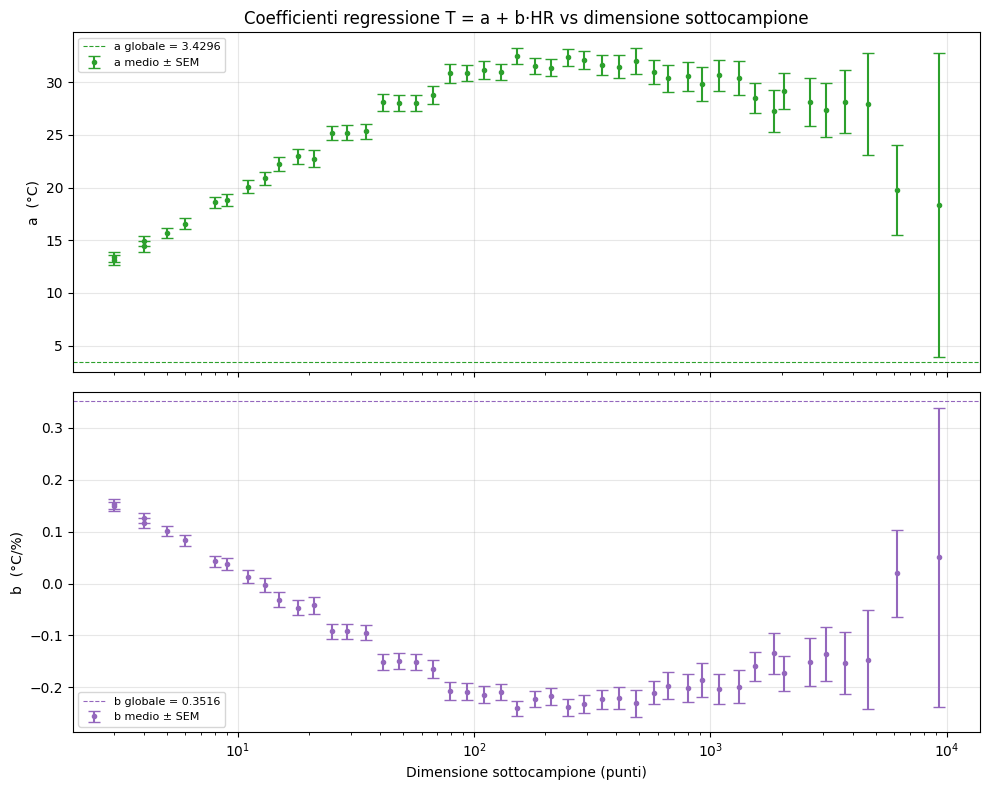

In [78]:
# ── Plot a ± Δa e b ± Δb vs dimensione sottocampione ────────────────
a_mean  = np.array([np.mean(a) for a in a_list])
a_sem   = np.array([np.std(a, ddof=1) / np.sqrt(len(a)) for a in a_list])
b_mean  = np.array([np.mean(b) for b in b_list])
b_sem   = np.array([np.std(b, ddof=1) / np.sqrt(len(b)) for b in b_list])

# regressione sul campione intero come riferimento
res_global = linregress(HR, T)
a_global, b_global = res_global.intercept, res_global.slope

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_a.errorbar(chunk_sizes_lr, a_mean, yerr=a_sem,
              fmt='.', capsize=4, color='tab:green', label='a medio ± SEM')
ax_a.axhline(a_global, color='tab:green', linestyle='--', linewidth=0.8,
             label=f'a globale = {a_global:.4f}')
ax_a.set_ylabel('a  (°C)')
ax_a.legend(fontsize=8)
ax_a.grid(alpha=0.3)
ax_a.set_title('Coefficienti regressione T = a + b·HR vs dimensione sottocampione')

ax_b.errorbar(chunk_sizes_lr, b_mean, yerr=b_sem,
              fmt='.', capsize=4, color='tab:purple', label='b medio ± SEM')
ax_b.axhline(b_global, color='tab:purple', linestyle='--', linewidth=0.8,
             label=f'b globale = {b_global:.4f}')
ax_b.set_ylabel('b  (°C/%)')
ax_b.set_xlabel('Dimensione sottocampione (punti)')
ax_b.legend(fontsize=8)
ax_b.grid(alpha=0.3)

ax_a.set_xscale('log')
ax_b.set_xscale('log')

plt.tight_layout()
plt.show()

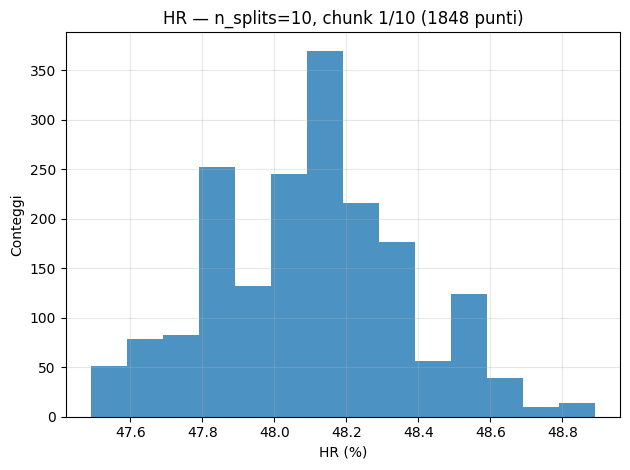

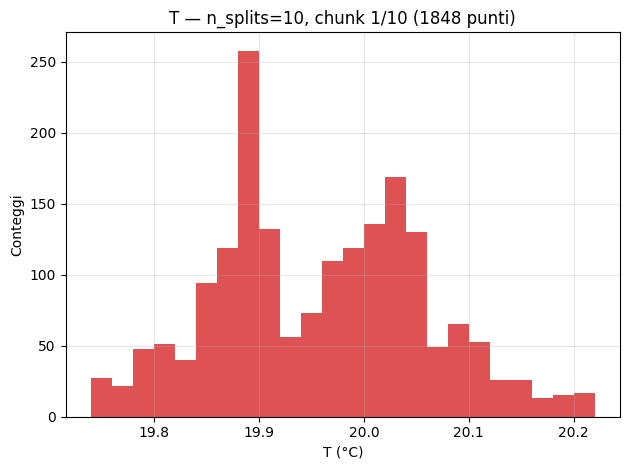

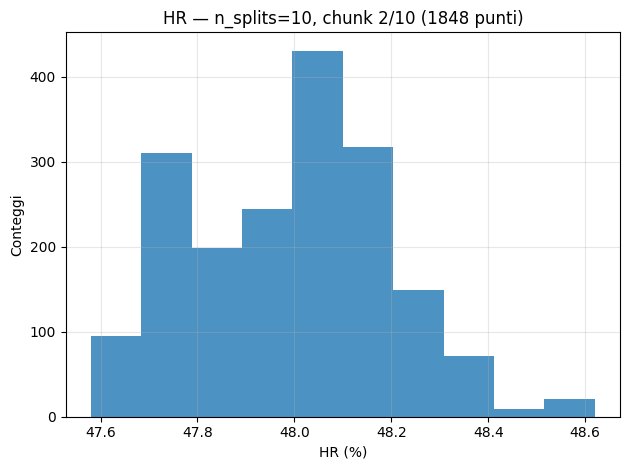

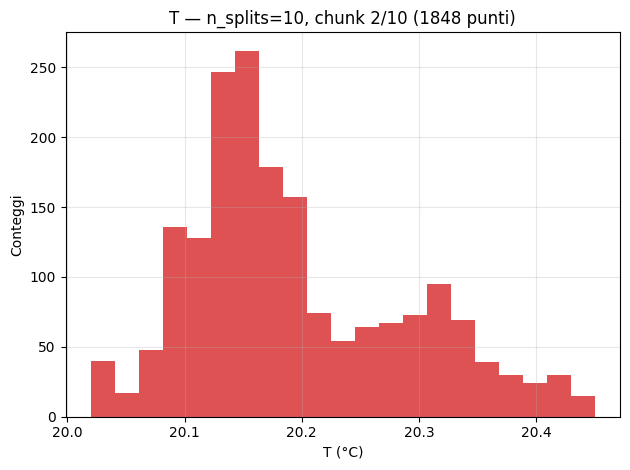

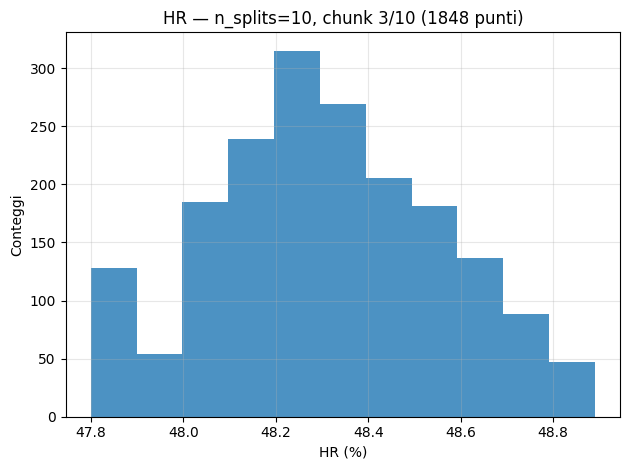

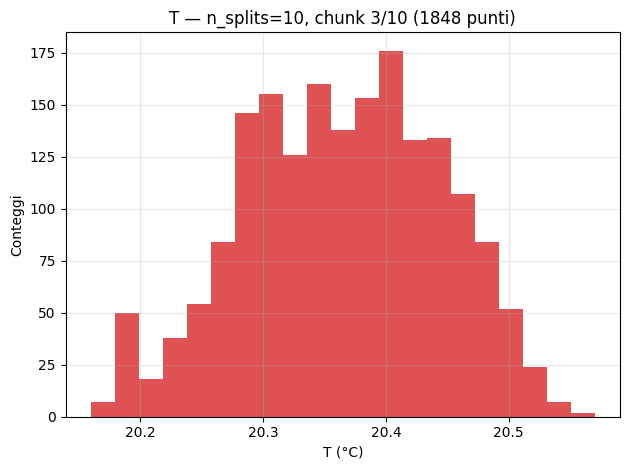

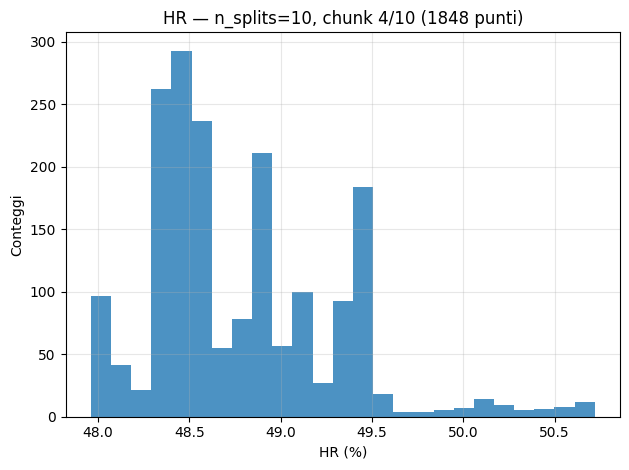

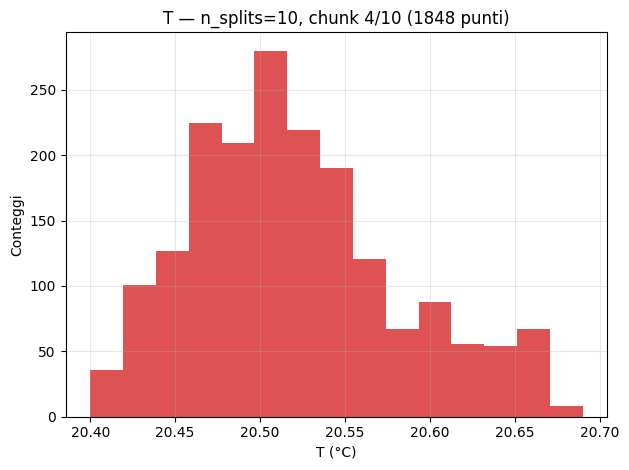

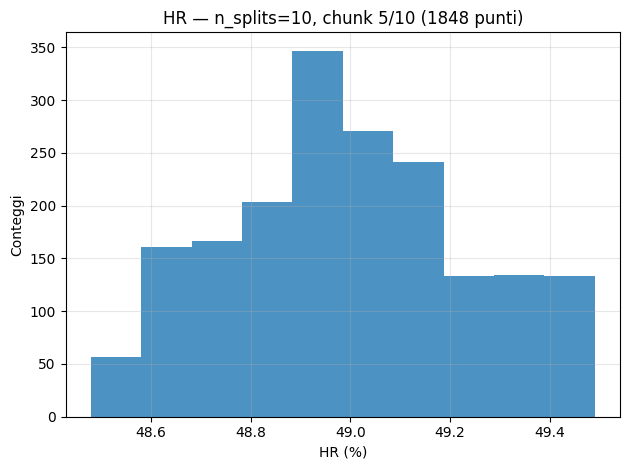

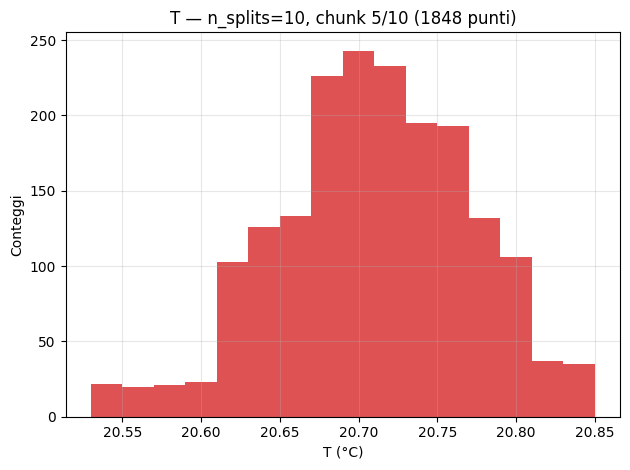

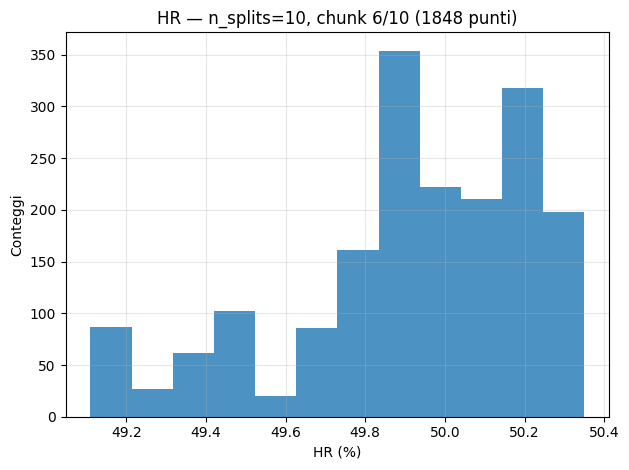

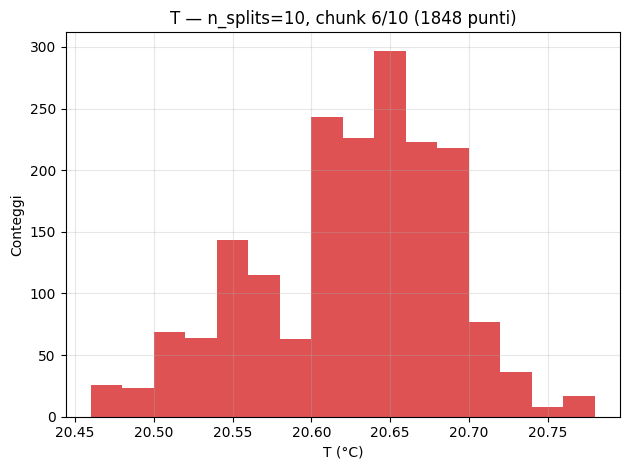

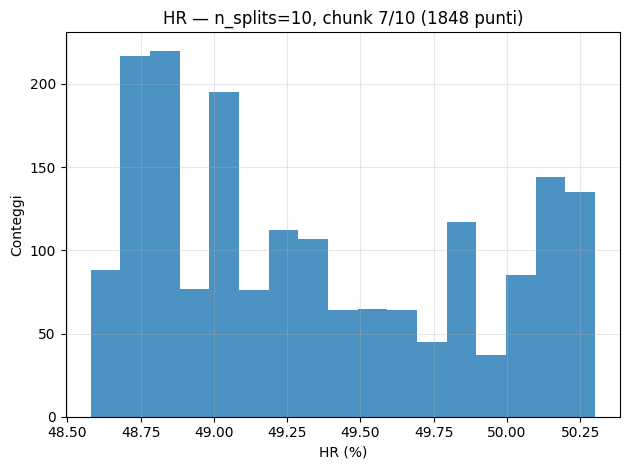

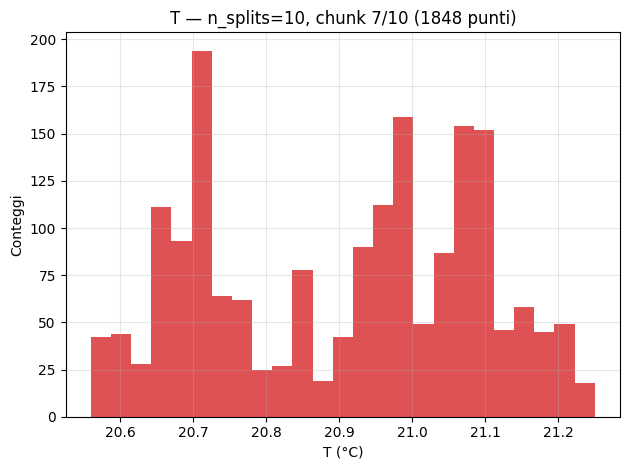

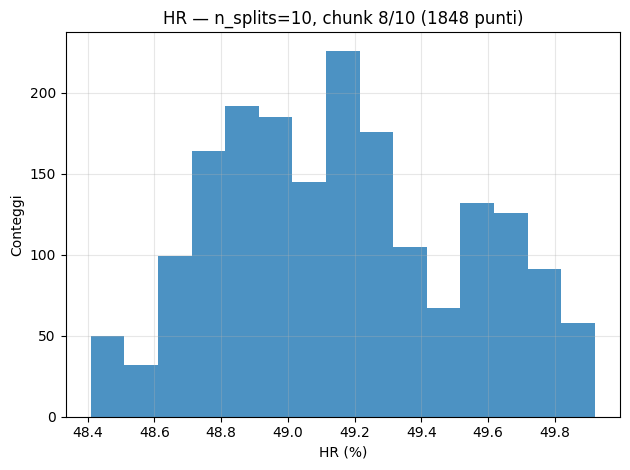

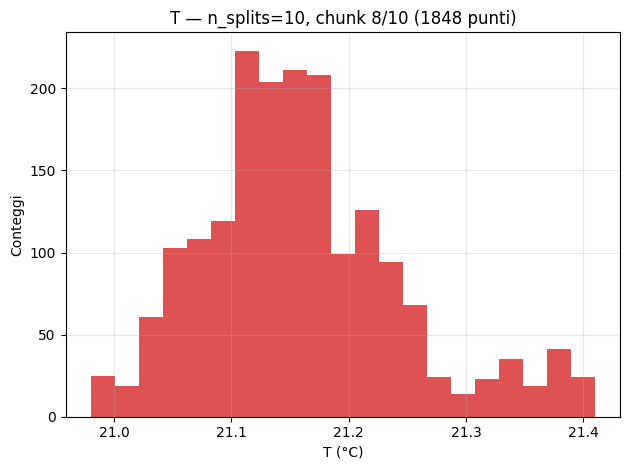

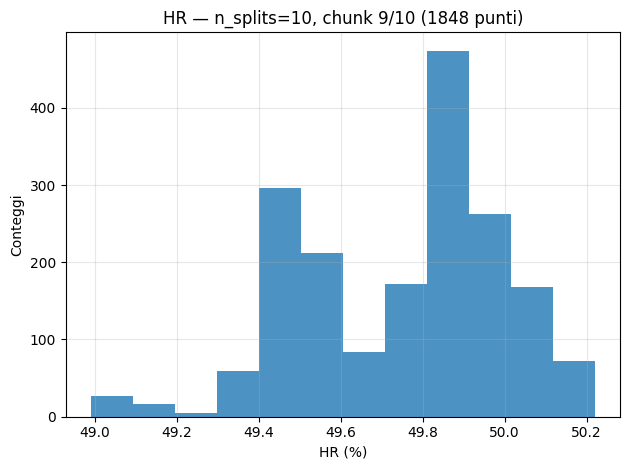

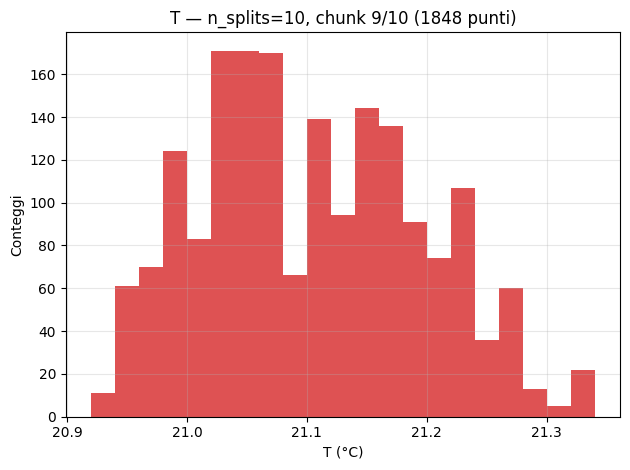

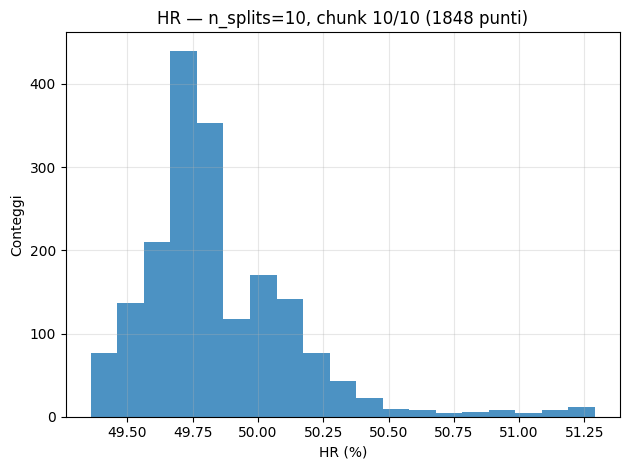

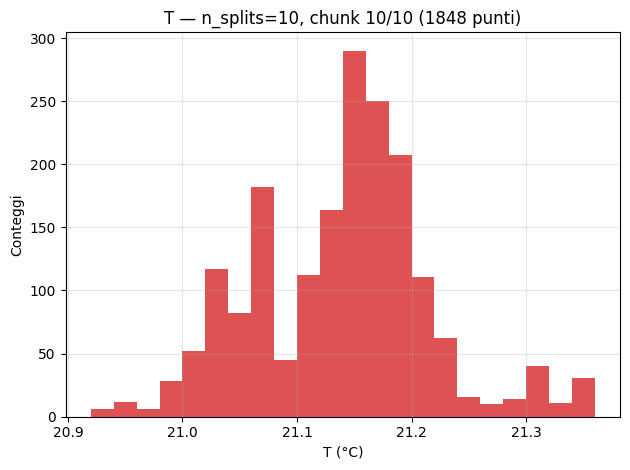

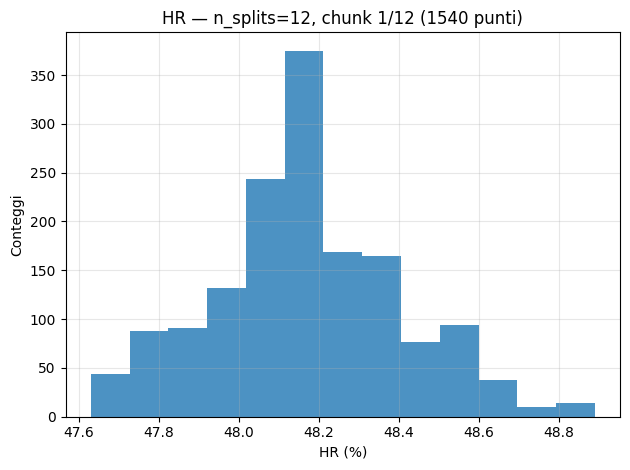

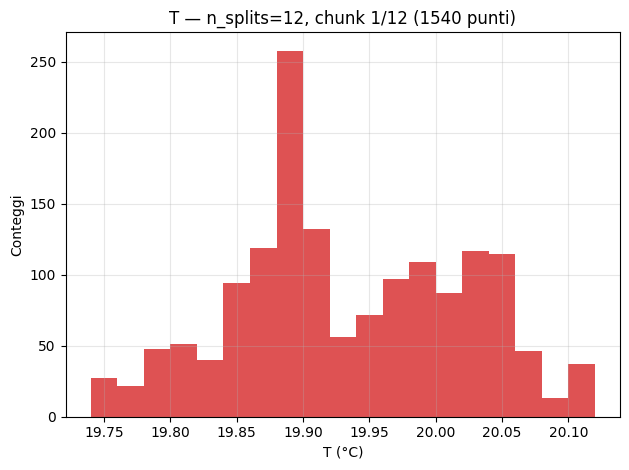

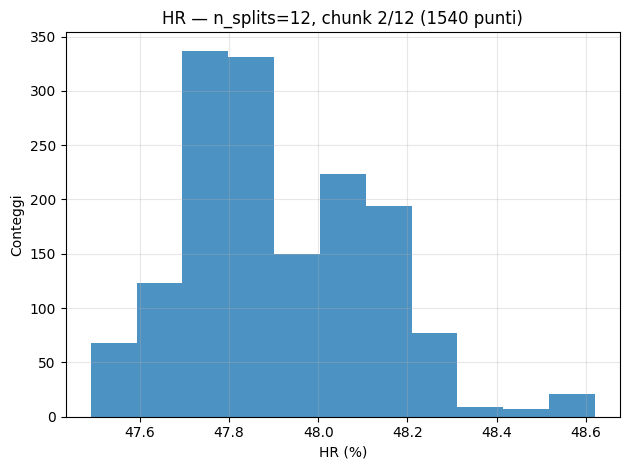

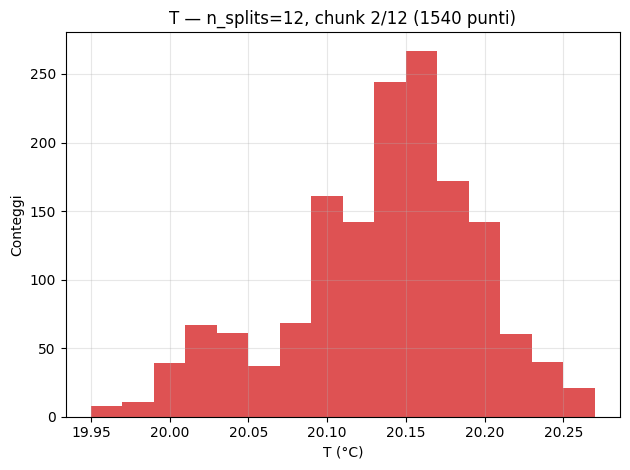

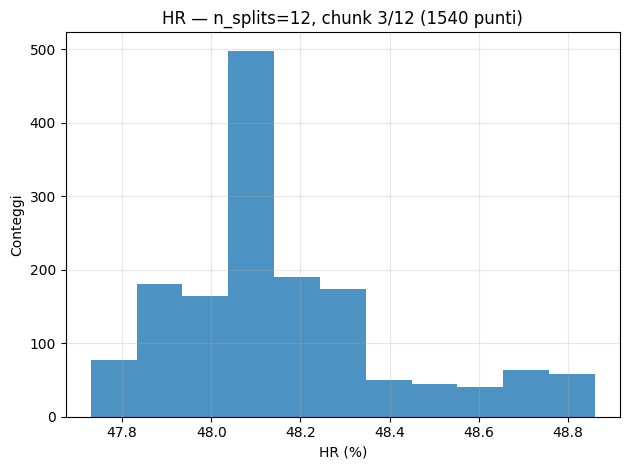

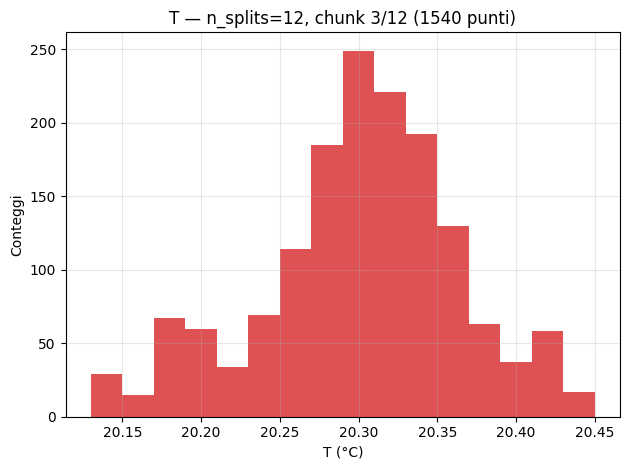

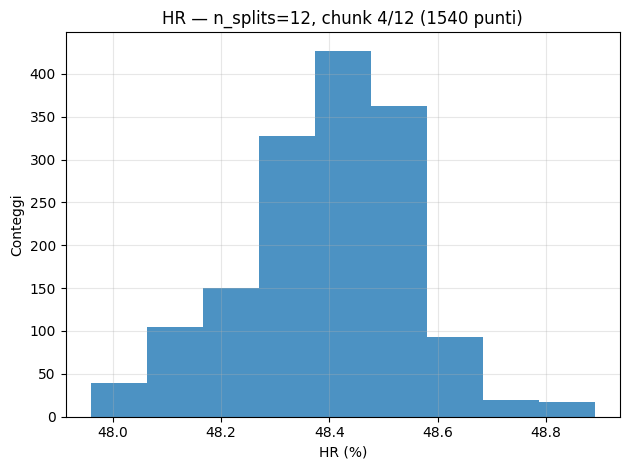

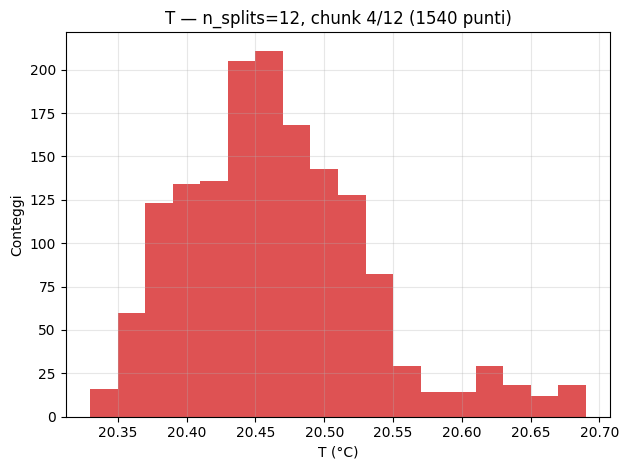

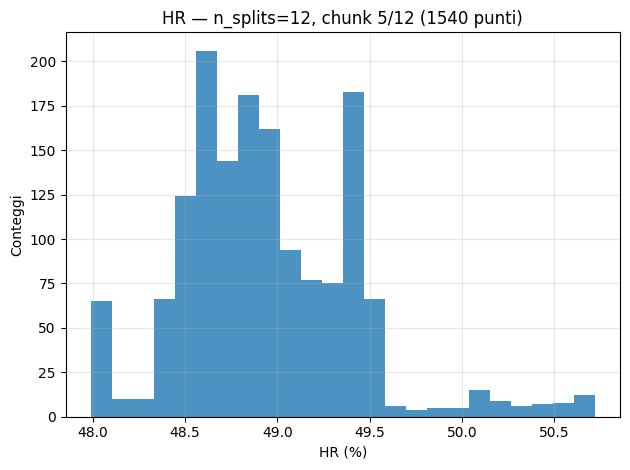

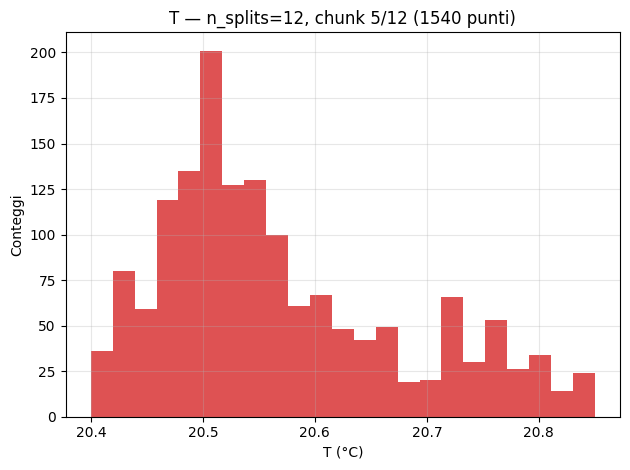

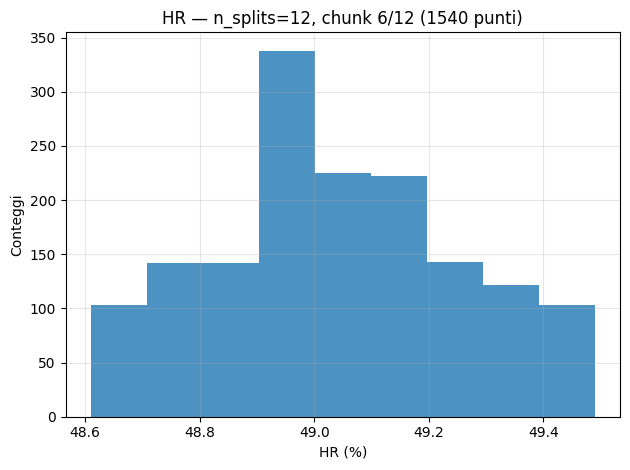

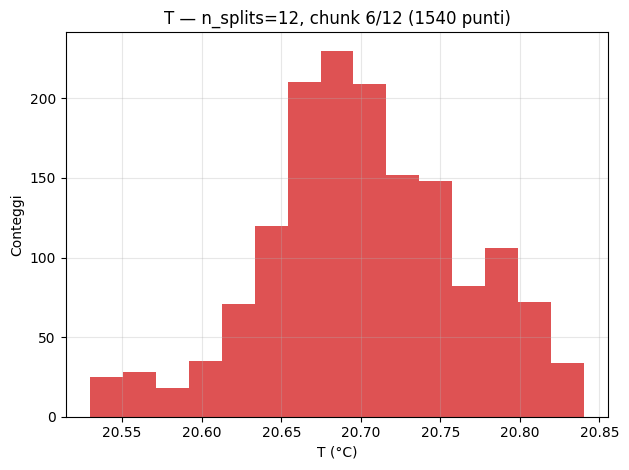

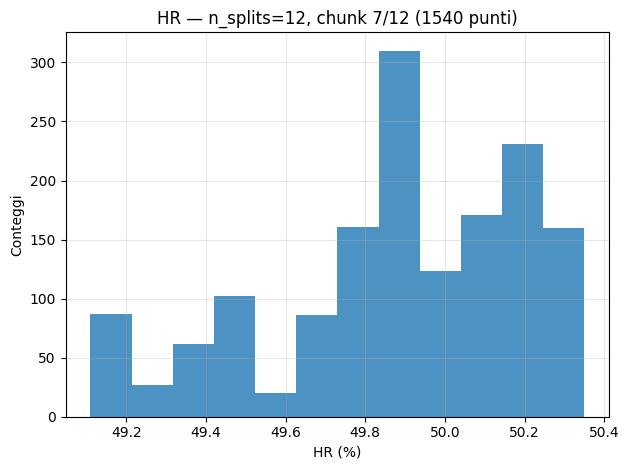

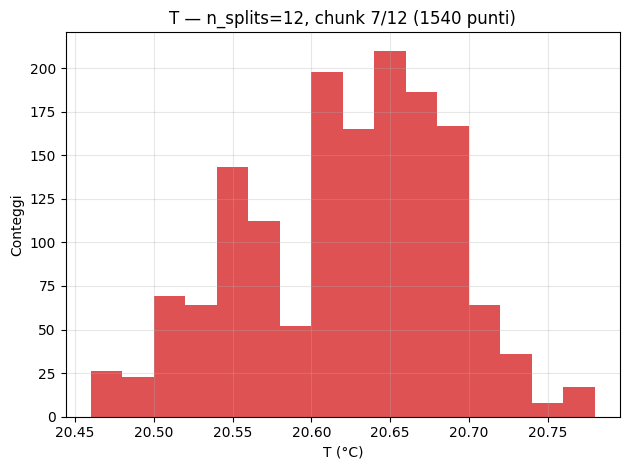

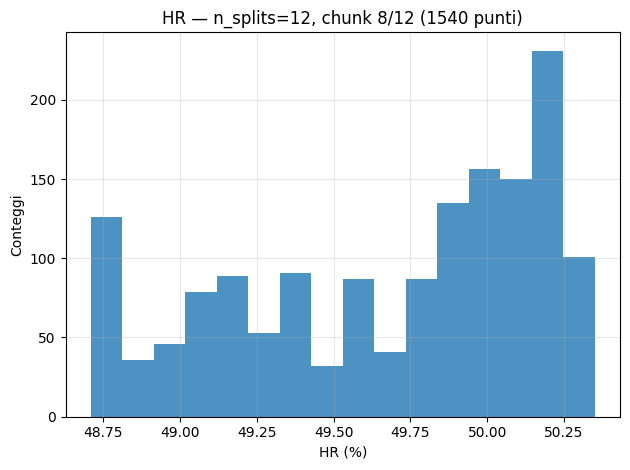

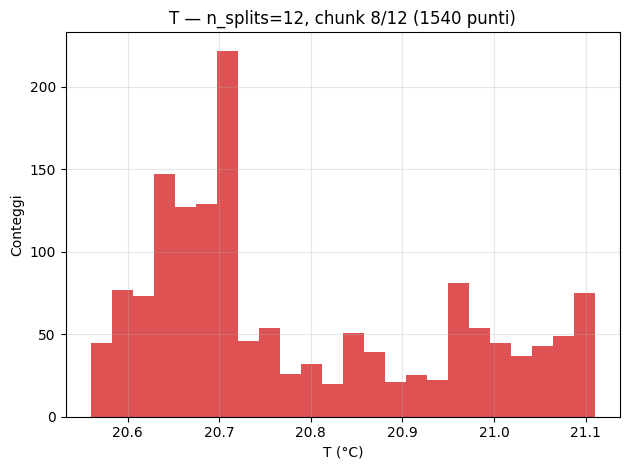

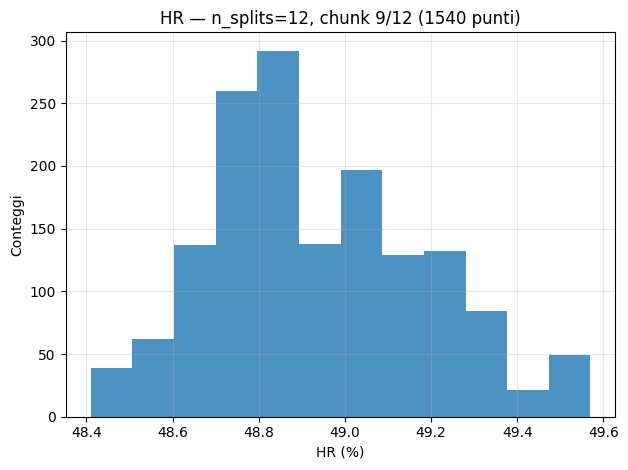

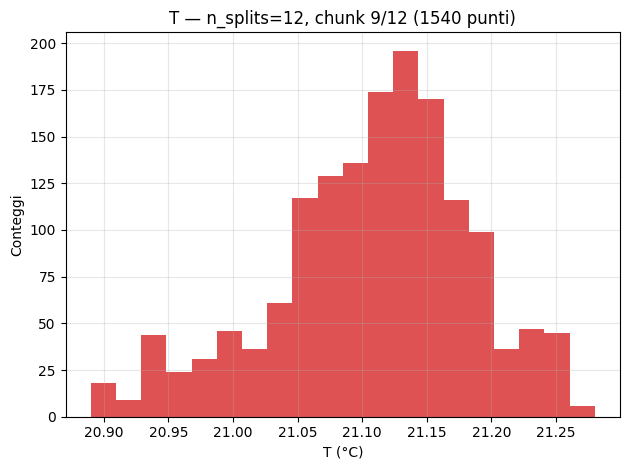

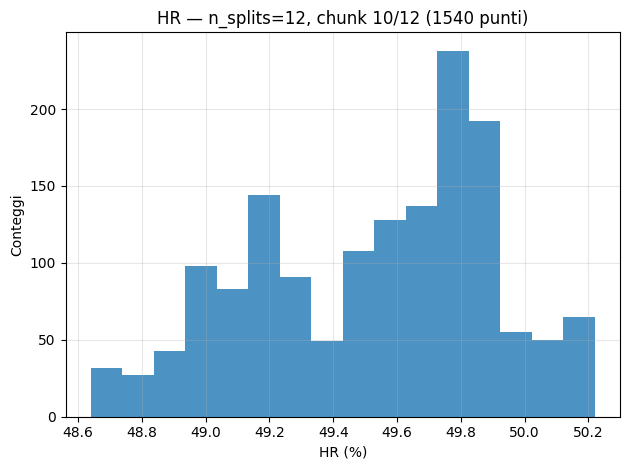

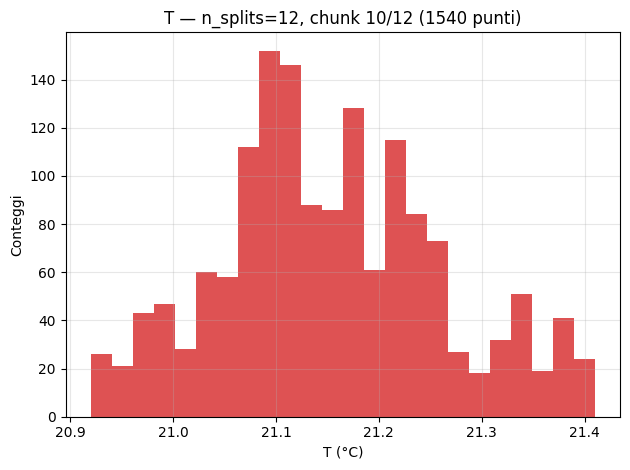

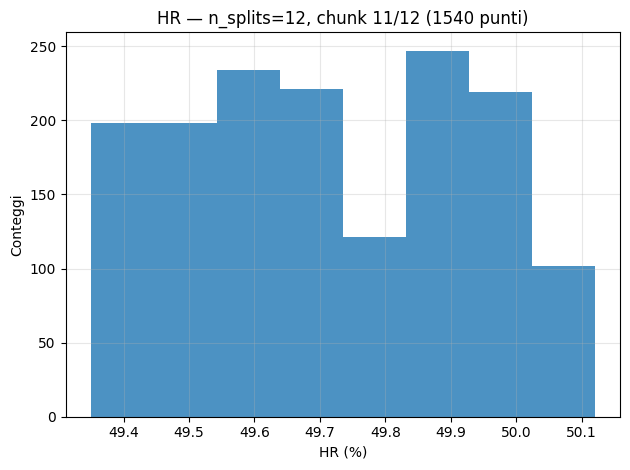

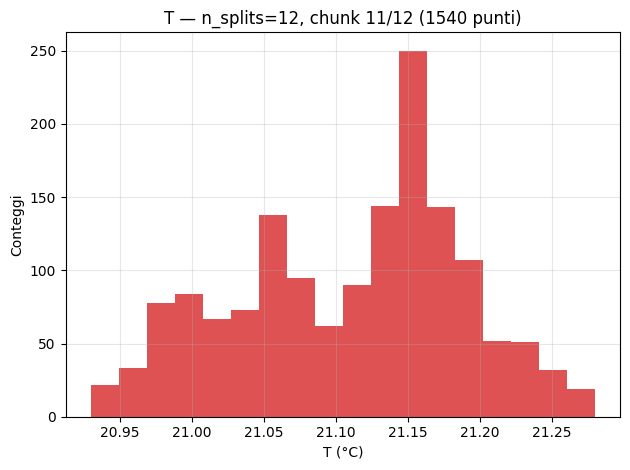

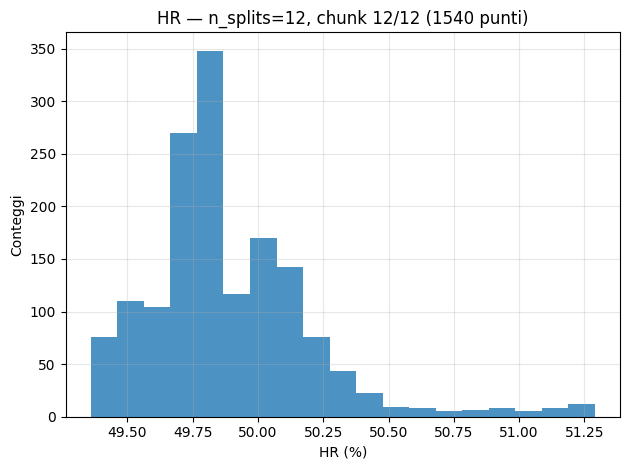

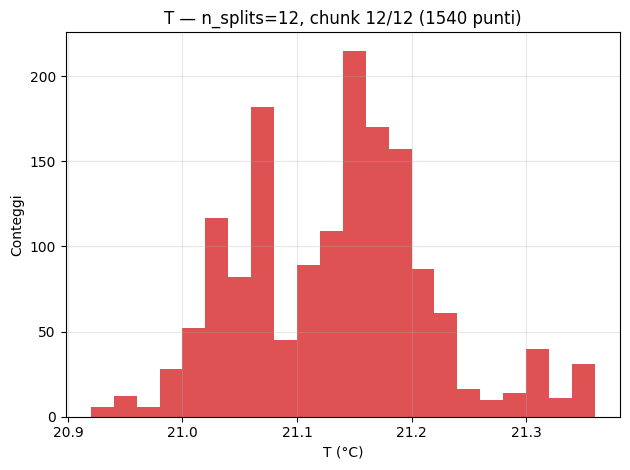

In [79]:
sens_HR = 0.05
sens_T  = 0.01
representative_splits = [10, 12]

for n_splits in representative_splits:
    chunk = N // n_splits
    if chunk < 3:
        continue

    for i in range(n_splits):
        sl = slice(i * chunk, (i + 1) * chunk)
        hr_chunk = HR[sl]
        t_chunk  = T[sl]

        n_bins_HR_phys = int(round((hr_chunk.max() - hr_chunk.min()) / (2 * sens_HR)))
        n_bins_T_phys  = int(round((t_chunk.max()  - t_chunk.min())  / (2 * sens_T)))
        n_bins_rice    = int(np.ceil(2 * chunk**(1/3)))
        n_bins_HR_i    = max(1, min(n_bins_HR_phys, n_bins_rice))
        n_bins_T_i     = max(1, min(n_bins_T_phys,  n_bins_rice))

        plt.figure()
        plt.hist(hr_chunk, bins=n_bins_HR_i, color='tab:blue', edgecolor='none', alpha=0.8)
        plt.xlabel('HR (%)')
        plt.ylabel('Conteggi')
        plt.title(f'HR — n_splits={n_splits}, chunk {i+1}/{n_splits} ({chunk} punti)')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.hist(t_chunk, bins=n_bins_T_i, color='tab:red', edgecolor='none', alpha=0.8)
        plt.xlabel('T (°C)')
        plt.ylabel('Conteggi')
        plt.title(f'T — n_splits={n_splits}, chunk {i+1}/{n_splits} ({chunk} punti)')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

$$\frac{r}{\Delta r} = r\sqrt{\frac{n - 2}{1 - r^2}}$$